# Assignment 4: Regularization

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?

Adding a penalty for large coefficients discourages the model from relying too heavily on any one feature or combination of features. This keeps the model simpler and less sensitive to noise, which can improve performance on new data.

2. How does regularization provide a way of exploring the bias-variance trade-off?

Regularization lets us control model complexity through the penalty parameter. With little regularization, the model may fit the training data closely but have high variance. With strong regularization, coefficients shrink and the model becomes more stable but more biased. Varying the penalty explores the bias-variance trade-off.

3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?

Ridge uses an L2 penalty and typically keeps all predictors in the model while shrinking their coefficients. LASSO uses an L1 penalty and often sets some coefficients exactly to zero, effectively selecting a smaller subset of features.

4. How do we typically scale variables for use in regularized regression? Why?

We usually standardize predictors to mean 0 and standard deviation 1 before regularized regression. This ensures the penalty treats all variables fairly, rather than penalizing variables differently just because they are measured on different scales.

5. How is the penalty $\alpha$ typically selected?

Cross-validation. You try many $α$ values, compute validation error for each, and choose the one with the best predictive performance.

6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

No. The penalty is part of the training objective used to estimate the coefficients, but cross-validated MSE should measure predictive accuracy on held-out data. We want to know how well the model predicts new observations, not how small the penalized objective is.

**Q2.** This is a case study on regularization.


1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.

In [6]:
import pandas as pd

df = pd.read_csv("cars_hw.csv")
df.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [7]:
df["Age"] = 2026 - df["Make_Year"]

In [8]:
X_raw = df[["Mileage_Run", "Age"]]
y = df["Price"]

In [9]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X_raw)

feature_names = poly.get_feature_names_out(["Mileage_Run", "Age"])
print(feature_names)

['Mileage_Run' 'Age' 'Mileage_Run^2' 'Mileage_Run Age' 'Age^2'
 'Mileage_Run^3' 'Mileage_Run^2 Age' 'Mileage_Run Age^2' 'Age^3']


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X_poly)

2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?

In [11]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()
linreg.fit(X, y)

LinearRegression()

In [12]:
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": linreg.coef_
})

coef_df

,Feature,Coefficient
0,Mileage_Run,9.117748e+05
1,Age,-2.481722e+05
2,Mileage_Run^2,-2.072926e+05
3,Mileage_Run Age,-1.671212e+06
4,Age^2,3.505507e+05
5,Mileage_Run^3,-6.514490e+04
6,Mileage_Run^2 Age,3.388195e+05
7,Mileage_Run Age^2,7.167816e+05
8,Age^3,-2.100379e+05


In [13]:
coef_df[coef_df["Feature"] == "Mileage_Run Age"]

,Feature,Coefficient
3,Mileage_Run Age,-1.671212e+06


The interaction coefficient between Mileage_Run and Age is negative. This means that when mileage and age are both high, their combined effect decreases the prediction more strongly than their separate effects alone.

3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)

In [14]:
import numpy as np
from sklearn.linear_model import LassoCV

alphas = np.logspace(1, 3, 20)

lasso_cv = LassoCV(alphas=alphas, cv=20, max_iter=100000)
lasso_cv.fit(X, y)

LassoCV(alphas=array([  10.        ,   12.74274986,   16.23776739,   20.69138081,
         26.36650899,   33.59818286,   42.81332399,   54.55594781,
         69.51927962,   88.58667904,  112.88378917,  143.84498883,
        183.29807108,  233.57214691,  297.63514416,  379.26901907,
        483.29302386,  615.84821107,  784.75997035, 1000.        ]),
        cv=20, max_iter=100000)

In [15]:
best_alpha = lasso_cv.alpha_
best_alpha

np.float64(88.58667904100822)

Using 20-fold cross-validation, the value of
$α$ selected by LASSO was 89. This is the penalty strength that minimized the average validation MSE across the folds.

4. Plot the cross-validated MSE by $\alpha$.

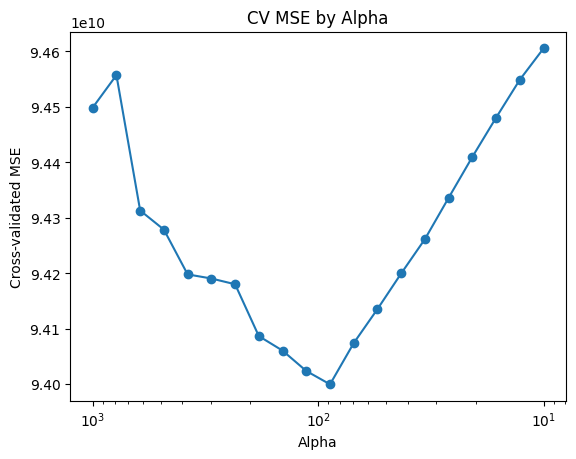

In [16]:
import matplotlib.pyplot as plt

mean_mse = lasso_cv.mse_path_.mean(axis=1)

plt.plot(lasso_cv.alphas_, mean_mse, marker='o')
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Cross-validated MSE")
plt.title("CV MSE by Alpha")
plt.gca().invert_xaxis()
plt.show()

5. Plot the coefficient paths by $\alpha$.

In [17]:
from sklearn.linear_model import Lasso

coefs = []

for a in alphas:
    lasso = Lasso(alpha=a, max_iter=100000)
    lasso.fit(X, y)
    coefs.append(lasso.coef_)

coefs = np.array(coefs)

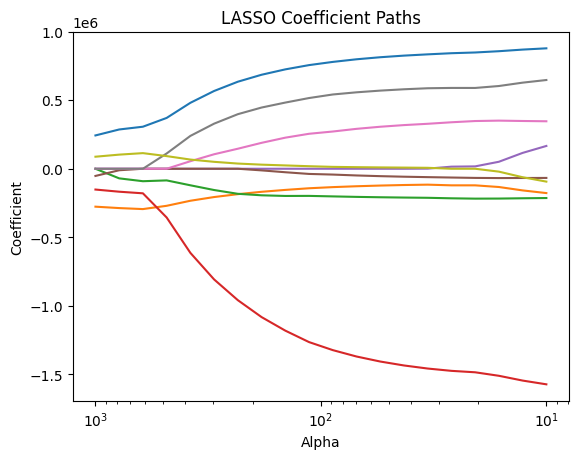

In [18]:
for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i], label=feature_names[i])

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Coefficient")
plt.title("LASSO Coefficient Paths")
plt.gca().invert_xaxis()
plt.show()

6. Which features are actually selected? What proportion are set equal to zero?

In [19]:
lasso_coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lasso_cv.coef_
})

lasso_coef_df

,Feature,Coefficient
0,Mileage_Run,7.790762e+05
1,Age,-1.339534e+05
2,Mileage_Run^2,-2.015634e+05
3,Mileage_Run Age,-1.322419e+06
4,Age^2,0.000000e+00
5,Mileage_Run^3,-4.240952e+04
6,Mileage_Run^2 Age,2.715062e+05
7,Mileage_Run Age^2,5.415432e+05
8,Age^3,1.374220e+04


In [20]:
selected = lasso_coef_df[lasso_coef_df["Coefficient"] != 0]
zeroed = lasso_coef_df[lasso_coef_df["Coefficient"] == 0]

selected

,Feature,Coefficient
0,Mileage_Run,7.790762e+05
1,Age,-1.339534e+05
2,Mileage_Run^2,-2.015634e+05
3,Mileage_Run Age,-1.322419e+06
5,Mileage_Run^3,-4.240952e+04
6,Mileage_Run^2 Age,2.715062e+05
7,Mileage_Run Age^2,5.415432e+05
8,Age^3,1.374220e+04


In [21]:
prop_zero = len(zeroed) / len(lasso_coef_df)
prop_zero

0.1111111111111111

The features selected by LASSO are the ones with nonzero coefficients: `Milage_Run`, `Age`, `Milage__Run^2`, `Milage_Run Age`, `Mileage_Run^3`, `Milage_Run^2 Age`, `Milage_Run Age^2`, and `Age^3`.
The proportion of coefficients set equal to zero is 0.11.
This shows that LASSO simplified the model by removing some polynomial terms that were less useful for prediction.

7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [22]:
compare_df = pd.DataFrame({
    "Feature": feature_names,
    "LinearRegression": linreg.coef_,
    "LASSO": lasso_cv.coef_
})

compare_df

,Feature,LinearRegression,LASSO
0,Mileage_Run,9.117748e+05,7.790762e+05
1,Age,-2.481722e+05,-1.339534e+05
2,Mileage_Run^2,-2.072926e+05,-2.015634e+05
3,Mileage_Run Age,-1.671212e+06,-1.322419e+06
4,Age^2,3.505507e+05,0.000000e+00
5,Mileage_Run^3,-6.514490e+04,-4.240952e+04
6,Mileage_Run^2 Age,3.388195e+05,2.715062e+05
7,Mileage_Run Age^2,7.167816e+05,5.415432e+05
8,Age^3,-2.100379e+05,1.374220e+04


Most coefficients decrease in magnitude under LASSO, and none meaningfully increase. At least one coefficient is set to zero (e.g., `Age^2`), showing feature selection. There is also a sign change (e.g., `Age^3`), likely due to correlation among polynomial terms and LASSO redistributing their effects.

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.

In [23]:
import pandas as pd

df = pd.read_csv("heart_failure_clinical_records_dataset.csv")
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [24]:
X_cont = df[["age", "ejection_fraction", "serum_creatinine"]]
X_bin = df[["anaemia", "diabetes", "high_blood_pressure", "smoking"]]
y = df["DEATH_EVENT"]

In [25]:
poly_cont = PolynomialFeatures(degree=3, include_bias=False)
X_cont_poly = poly_cont.fit_transform(X_cont)
cont_names = poly_cont.get_feature_names_out(["age", "ejection_fraction", "serum_creatinine"])

In [26]:
poly_bin = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_bin_inter = poly_bin.fit_transform(X_bin)
bin_names = poly_bin.get_feature_names_out(["anaemia", "diabetes", "high_blood_pressure", "smoking"])

In [27]:
X_full = np.hstack([X_cont_poly, X_bin_inter])
feature_names_full = np.concatenate([cont_names, bin_names])

In [28]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)

2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?

In [29]:
linreg2 = LinearRegression()
linreg2.fit(X_scaled, y)

coef_df2 = pd.DataFrame({
    "Feature": feature_names_full,
    "Coefficient": linreg2.coef_
})

coef_df2

,Feature,Coefficient
0,age,1.539156
1,ejection_fraction,-2.192494
2,serum_creatinine,-0.853588
3,age^2,-3.678654
4,age ejection_fraction,-0.600918
5,age serum_creatinine,1.841563
6,ejection_fraction^2,3.430976
7,ejection_fraction serum_creatinine,2.673394
8,serum_creatinine^2,-2.647041
9,age^3,1.993135


Some coefficient signs may appear contradictory because the same variable has both positive and negative coefficients across different powers (e.g., age, age², age³). This happens because the relationship between the predictors and the outcome is nonlinear, so a single linear term cannot capture the full effect. Higher-order terms and interactions allow the effect of a variable to change depending on its value or in combination with other variables, which resolves these apparent contradictions.

3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)

In [30]:
alphas2 = np.logspace(-5, 5, 30)

lasso_cv2 = LassoCV(alphas=alphas2, cv=20, max_iter=100000)
lasso_cv2.fit(X_scaled, y)

lasso_cv2.alpha_

np.float64(0.005736152510448681)

4. Plot the cross-validated MSE by $\alpha$.

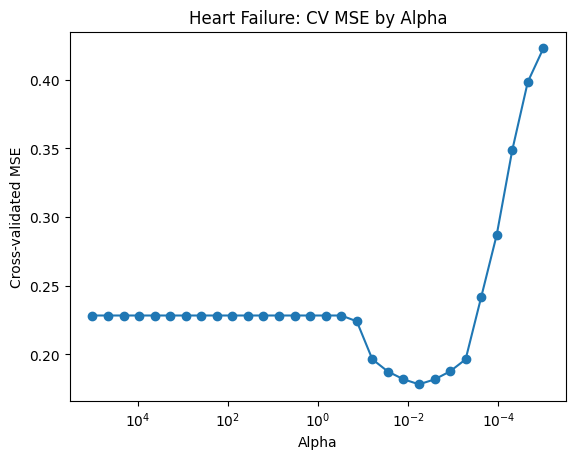

In [31]:
mean_mse2 = lasso_cv2.mse_path_.mean(axis=1)

plt.plot(lasso_cv2.alphas_, mean_mse2, marker='o')
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Cross-validated MSE")
plt.title("Heart Failure: CV MSE by Alpha")
plt.gca().invert_xaxis()
plt.show()

5. Plot the coefficient paths by $\alpha$.

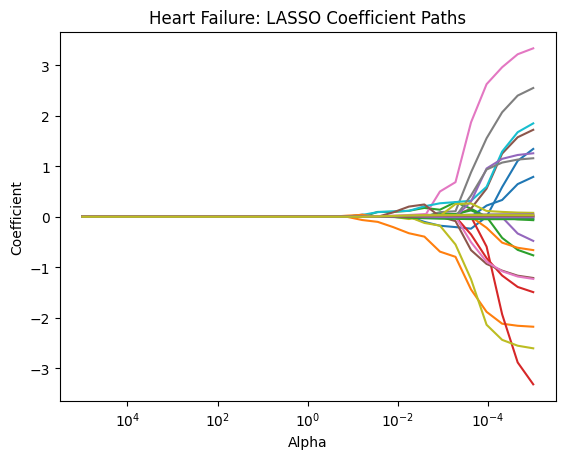

In [32]:
coefs2 = []

for a in alphas2:
    lasso = Lasso(alpha=a, max_iter=100000)
    lasso.fit(X_scaled, y)
    coefs2.append(lasso.coef_)

coefs2 = np.array(coefs2)

for i in range(coefs2.shape[1]):
    plt.plot(alphas2, coefs2[:, i])

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Coefficient")
plt.title("Heart Failure: LASSO Coefficient Paths")
plt.gca().invert_xaxis()
plt.show()

6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [33]:
lasso_coef_df2 = pd.DataFrame({
    "Feature": feature_names_full,
    "Coefficient": lasso_cv2.coef_
})

selected2 = lasso_coef_df2[lasso_coef_df2["Coefficient"] != 0]
zeroed2 = lasso_coef_df2[lasso_coef_df2["Coefficient"] == 0]

prop_zero2 = len(zeroed2) / len(lasso_coef_df2)

print(selected2)
print(prop_zero2)

                                 Feature  Coefficient
1                      ejection_fraction    -0.326124
2                       serum_creatinine     0.117426
9                                  age^3     0.116214
15                   ejection_fraction^3     0.200750
16  ejection_fraction^2 serum_creatinine     0.034419
18                    serum_creatinine^3    -0.045558
19                               anaemia     0.013163
22                               smoking    -0.019828
23                      anaemia diabetes     0.000310
26          diabetes high_blood_pressure     0.024535
27                      diabetes smoking     0.017410
28           high_blood_pressure smoking     0.025812
0.5862068965517241


LASSO selects a smaller set of features, including ejection_fraction, serum_creatinine, and a few higher-order and interaction terms, while setting about 58.6% of coefficients to zero. Compared to linear regression, coefficients are generally smaller and many are eliminated, with no meaningful increases in magnitude, though some signs may change due to correlated predictors. The LASSO model is more interpretable and stable because it removes redundant terms. From a bias-variance perspective, LASSO adds some bias but reduces variance, leading to a better overall model.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?

$$
J(b_0, b_1) = \frac{1}{n} \sum_{i=1}^{n} (\tilde{y}_i - b_0 - b_1 \tilde{x}_i)^2 + \alpha b_1^2
$$

The intercept \($b_0$\) is not penalized.

2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.

Step 1: Differentiate with respect to \($b_0$\)

$$
\frac{\partial J}{\partial b_0}
=
\frac{\partial}{\partial b_0}
\left[
\frac{1}{n}\sum_{i=1}^n(\tilde y_i-b_0-b_1\tilde x_i)^2+\alpha b_1^2
\right]
$$

$$
\frac{\partial J}{\partial b_0}
=
\frac{1}{n}\sum_{i=1}^n 2(\tilde y_i-b_0-b_1\tilde x_i)(-1)
$$

$$
\frac{\partial J}{\partial b_0}
=
-\frac{2}{n}\sum_{i=1}^n(\tilde y_i-b_0-b_1\tilde x_i)
$$

$$
-\frac{2}{n}\sum_{i=1}^n(\tilde y_i-b_0-b_1\tilde x_i)=0
$$

$$
\sum_{i=1}^n(\tilde y_i-b_0-b_1\tilde x_i)=0
$$

$$
\sum_{i=1}^n \tilde y_i - \sum_{i=1}^n b_0 - \sum_{i=1}^n b_1\tilde x_i = 0
$$

$$
\sum_{i=1}^n \tilde y_i - nb_0 - b_1\sum_{i=1}^n \tilde x_i = 0
$$

$$
\sum_{i=1}^n \tilde y_i = 0
\qquad\text{and}\qquad
\sum_{i=1}^n \tilde x_i = 0
$$

$$
0-nb_0-b_1(0)=0
$$

$$
-nb_0=0
$$

$$
\boxed{b_0=0}
$$

Step 2: Differentiate with respect to \($b_1$\)

$$
J(b_0,b_1)=\frac{1}{n}\sum_{i=1}^n(\tilde y_i-b_0-b_1\tilde x_i)^2+\alpha b_1^2
$$

$$
\frac{\partial J}{\partial b_1}
=
\frac{1}{n}\sum_{i=1}^n 2(\tilde y_i-b_0-b_1\tilde x_i)(-\tilde x_i)+2\alpha b_1
$$

$$
\frac{\partial J}{\partial b_1}
=
-\frac{2}{n}\sum_{i=1}^n \tilde x_i(\tilde y_i-b_0-b_1\tilde x_i)+2\alpha b_1
$$

$$
-\frac{2}{n}\sum_{i=1}^n \tilde x_i(\tilde y_i-b_0-b_1\tilde x_i)+2\alpha b_1=0
$$

$$
-\frac{2}{n}\sum_{i=1}^n \tilde x_i(\tilde y_i-b_1\tilde x_i)+2\alpha b_1=0
$$

$$
-\frac{2}{n}\sum_{i=1}^n(\tilde x_i\tilde y_i-b_1\tilde x_i^2)+2\alpha b_1=0
$$

$$
-\frac{2}{n}\sum_{i=1}^n \tilde x_i\tilde y_i
+\frac{2}{n}\sum_{i=1}^n b_1\tilde x_i^2
+2\alpha b_1=0
$$

$$
-\frac{2}{n}\sum_{i=1}^n \tilde x_i\tilde y_i
+\frac{2b_1}{n}\sum_{i=1}^n \tilde x_i^2
+2\alpha b_1=0
$$

$$
-\frac{1}{n}\sum_{i=1}^n \tilde x_i\tilde y_i
+b_1\frac{1}{n}\sum_{i=1}^n \tilde x_i^2
+\alpha b_1=0
$$

$$
b_1\frac{1}{n}\sum_{i=1}^n \tilde x_i^2+\alpha b_1
=
\frac{1}{n}\sum_{i=1}^n \tilde x_i\tilde y_i
$$

$$
b_1\left(\frac{1}{n}\sum_{i=1}^n \tilde x_i^2+\alpha\right)
=
\frac{1}{n}\sum_{i=1}^n \tilde x_i\tilde y_i
$$

$$
\boxed{
b_1=
\frac{\frac{1}{n}\sum_{i=1}^n \tilde x_i\tilde y_i}
{\frac{1}{n}\sum_{i=1}^n \tilde x_i^2+\alpha}
}
$$

So the Ridge solution is:

$$
\boxed{b_0=0,\qquad
b_1=
\frac{\frac{1}{n}\sum_{i=1}^n \tilde x_i\tilde y_i}
{\frac{1}{n}\sum_{i=1}^n \tilde x_i^2+\alpha}}
$$

3. How does increasing $\alpha$ change the slope coefficient?

From the formula

$$
b_1=
\frac{\frac{1}{n}\sum_{i=1}^n \tilde x_i\tilde y_i}
{\frac{1}{n}\sum_{i=1}^n \tilde x_i^2+\alpha},
$$

increasing \( $\alpha$\) makes the denominator larger. As a result, the magnitude of \($b_1$\) gets smaller, so the coefficient is shrunk toward zero.

4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

If we replace the Ridge penalty with the LASSO penalty, the objective becomes

$$
J(b_0,b_1)=\frac{1}{n}\sum_{i=1}^n(\tilde y_i-b_0-b_1\tilde x_i)^2+\alpha |b_1|.
$$

The challenge is that \( $|b_1| $\) is not differentiable at \($b_1=0$\). That means the usual derivative method breaks down exactly at the point where LASSO may set the coefficient equal to zero.

This is why LASSO can produce exact zeros and perform feature selection.

In the one-variable centered case, \($b_1=0$\) is optimal when the data signal is not strong enough to overcome the penalty:

$$
\left|\frac{1}{n}\sum_{i=1}^n \tilde x_i\tilde y_i\right|\le \alpha
\quad\Rightarrow\quad
b_1=0.
$$